### Definición del Perfil Sociodemográfico del Empleado (Rapid Express)
**Equipo 28 | Analistas:** Emilio, Nuria (Perfil y Desempeño)

Atendiendo a las directrices exactas de dirección, procedemos a trazar el arquetipo de nuestra plantilla basándonos **estrictamente en variables sociodemográficas puras**. 

Para garantizar el rigor del análisis, hemos aislado exclusivamente los datos de Edad, Nivel Educativo y Cargas Familiares (Hijos), dejando fuera variables económicas, operativas o médicas. El objetivo es entender la estructura poblacional y social básica de las personas que componen la empresa.

### Importación de librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Cargamos el dataset limpio
df = pd.read_csv("data_cleaning_2026_20_04.csv")

# Nos quedamos solo con los 36 empleados únicos
df_empleados = df.drop_duplicates(subset=['ID']).copy()

# Resumen de las 3 variables estrictamente sociodemográficas
print(f"Perfil Sociodemográfico Real (Sobre {len(df_empleados)} empleados únicos)")

print("\n1. Distribución Educativa:")
educacion_pct = (df_empleados['Education_mapped'].value_counts(normalize=True) * 100).round(1)
display(educacion_pct.astype(str) + ' %')

print("\n2. Estadísticas de Edad y Cargas Familiares (Hijos):")
vars_socio = ['Age', 'Son']
display(df_empleados[vars_socio].describe().round(1).loc[['mean', 'min', '50%', 'max']])

Perfil Sociodemográfico Real (Sobre 36 empleados únicos)

1. Distribución Educativa:


Education_mapped
high_school          77.8 %
graduate             11.1 %
postgraduate          8.3 %
master_and_doctor     2.8 %
Name: proportion, dtype: object


2. Estadísticas de Edad y Cargas Familiares (Hijos):


,Age,Son
mean,38.3,1.1
min,27.0,0.0
50%,37.5,1.0
max,58.0,4.0


Representamos este arquetipo sociodemográfico depurado visualmente:

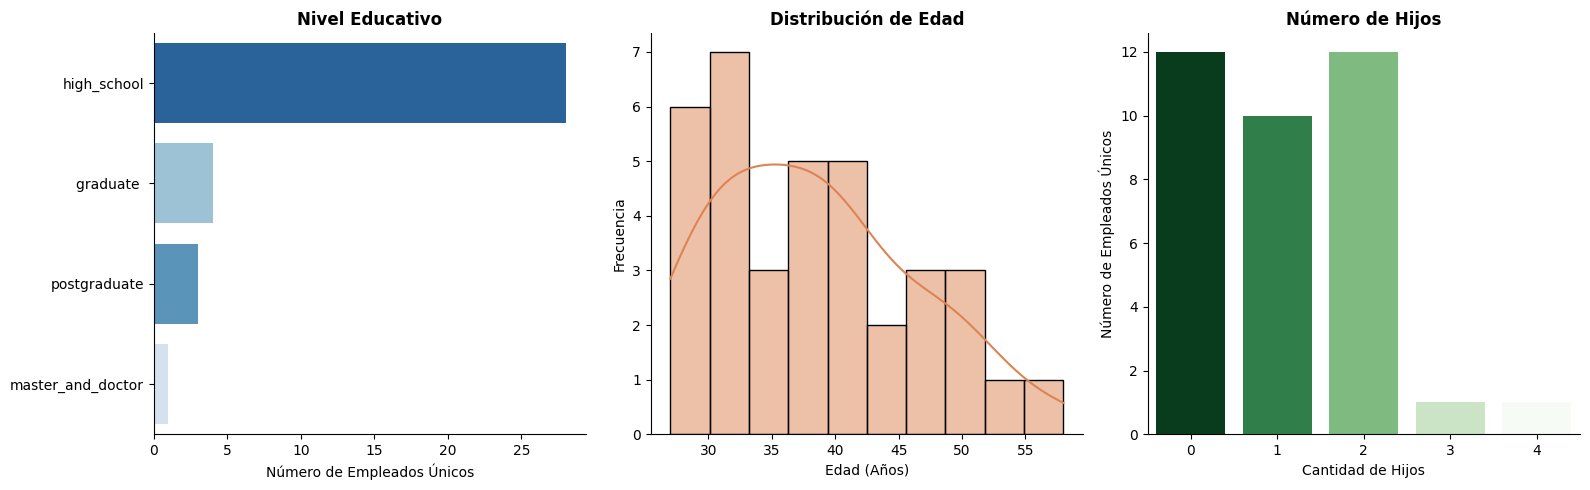

In [11]:
# Panel Visual Sociodemográfico
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Nivel Educativo (Paleta de azules)
sns.countplot(data=df_empleados, y='Education_mapped', hue='Education_mapped', 
              order=df_empleados['Education_mapped'].value_counts().index, 
              palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title('Nivel Educativo', fontweight='bold')
axes[0].set_xlabel('Número de Empleados Únicos')
axes[0].set_ylabel('')

# Gráfico 2: Distribución de la Edad (Color Terracota)
sns.histplot(data=df_empleados, x='Age', bins=10, kde=True, color='#DD8452', ax=axes[1])
axes[1].set_title('Distribución de Edad', fontweight='bold')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Frecuencia')

# Gráfico 3: Cargas Familiares (Hijos) (Paleta de verdes)
sns.countplot(data=df_empleados, x='Son', hue='Son', 
              palette='Greens_r', legend=False, ax=axes[2])
axes[2].set_title('Número de Hijos', fontweight='bold')
axes[2].set_xlabel('Cantidad de Hijos')
axes[2].set_ylabel('Número de Empleados Únicos')

# Mejora estética general
sns.despine()
plt.tight_layout()
plt.show()

### Conclusiones: El Arquetipo Sociodemográfico

Al observar a los empleados únicos, la radiografía sociodemográfica pura de Rapid Express nos muestra un arquetipo muy consolidado:
* **Un trabajador/a operativo de 38 años** (la media real sube al limpiar el sesgo de ausencias), con un nivel de estudios de **secundaria** (presente en el 77.8% de la plantilla), y que tiene **1 o ningún hijo** a su cargo.

**Implicaciones para el Diseño de Políticas de Talento:**
Conociendo esta estructura sociodemográfica pura, las políticas propuestas de RRHH más eficaces y adaptadas a sus necesidades reales serán:
1. **Planes de micro-formación y Upskilling:** Al tener una abrumadora mayoría de empleados en el nivel educativo básico, las políticas de retención deben enfocarse en el desarrollo profesional interno. No necesitan másteres universitarios, sino certificaciones técnicas operativas.
2. **Políticas de conciliación segmentadas:** Aunque la mediana es 1 hijo, el gráfico muestra un grupo relevante de empleados con 2, 3 o hasta 4 hijos. Dado que la plantilla está en una edad de madurez vital (media de 38 años), ofrecer flexibilidad horaria (como bolsas de horas para emergencias familiares) será un beneficio social de alto impacto para retener el talento de este grupo demográfico.